# The Product Pricer Continued

A model that can estimate how much something costs, from its description.

## Baseline Models 

Today we work on the simplest models to act as a starting point that we will beat.

### Traditional ML models
We will quickly set up these solutions to give us a starting point

1. Feature engineering & Linear Regression
2. Bag of Words & Linear Regression (LinearRegression)
3. word2vec & Linear Regression (Word2Vec, LinearRegression)
4. word2vec & Random Forest (Word2Vec, RandomForestRegressor)
5. word2vec & SVR (Word2Vec, LinearSVR)

In [1]:
# imports

import os
import math
import json
import random
from dotenv import load_dotenv
from huggingface_hub import login
import matplotlib.pyplot as plt
import numpy as np
import pickle
from collections import Counter

In [2]:
# More imports for our traditional machine learning

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

## NLP imports

In the next cell, we have more imports for our NLP related machine learning.  
If the gensim import gives you an error like "Cannot import name 'triu' from 'scipy.linalg' then please run in another cell:  
`!pip install "scipy<1.13"`  
As described on StackOverflow [here](https://stackoverflow.com/questions/78279136/importerror-cannot-import-name-triu-from-scipy-linalg-when-importing-gens).  
Many thanks to students Arnaldo G and Ard V for sorting this.

In [3]:
# NLP related imports
# !pip install -q scipy>=1.6.0 gensim
from sklearn.feature_extraction.text import CountVectorizer
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess

In [4]:
# Finally, more imports for more advanced machine learning

from sklearn.svm import LinearSVR, SVR
from sklearn.ensemble import RandomForestRegressor

In [5]:
# Constants - used for printing to stdout in color

GREEN = "\033[92m"
YELLOW = "\033[93m"
RED = "\033[91m"
RESET = "\033[0m"
COLOR_MAP = {"red":RED, "orange": YELLOW, "green": GREEN}

In [6]:
# environment

load_dotenv(override=True)
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
os.environ['ANTHROPIC_API_KEY'] = os.getenv('ANTHROPIC_API_KEY', 'your-key-if-not-using-env')
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN', 'your-key-if-not-using-env')

In [7]:
# Log in to HuggingFace

hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [8]:
# One more import after logging in

from items import Item

In [9]:
%matplotlib inline

# Loading the pkl files

Let's avoid curating all our data again! Load in the pickle files

If you didn't already create these in Day 2, you can also download them from my google drive (you'll also find the slides here):  
https://drive.google.com/drive/folders/1JwNorpRHdnf_pU0GE5yYtfKlyrKC3CoV?usp=sharing

But note that the files are quite large - you might need to get a coffee!

In [10]:
with open('train_lite.pkl', 'rb') as file:
    train = pickle.load(file)

with open('test_lite.pkl', 'rb') as file:
    test = pickle.load(file)

In [11]:
# Remind ourselves the training prompt

print(train[0].prompt)

How much does this cost to the nearest dollar?

E-repair Complete Full Set Screws Replacement for iPhone 7
1x Full screw set for iPhone 7 1x Clean Wiper Come with bottom screws 2x gold, 2x silver, 2x black. Including Clean Wiper with E-REPAIR LOGO Compatible with iPhone 7 It is full set screws to assemble a complete phone. Including bottom Pentalobe Screws black, silver and gold colors Dimensions 2.99 x 2.01 x 0.2 inches, Weight 1.58 ounces, model number Rank Cell Phones & Accessories 57932, Cell Phone Replacement Parts 1301, Is Discontinued No, Other display features Wireless, Manufacturer E-REPAIR, Available December 4, 2016

Price is $6.00


In [12]:
# Remind a test prompt

print(train[0].price)

6.4


## Unveiling a mighty script that we will use a lot!

A rather pleasing Test Harness that will evaluate any model against 250 items from the Test set

And show us the results in a visually satisfying way.

You write a function of this form:

```
def my_prediction_function(item):
    # my code here
    return my_estimate
```

And then you call:

`Tester.test(my_prediction_function)`

To evaluate your model.

In [13]:
class Tester:

    def __init__(self, predictor, title=None, data=None, size=250, print_detail=False):
        self.predictor = predictor
        self.data = data or test  # 預設資料來源為 test
        self.title = title or predictor.__name__.replace("_", " ").title()
        self.size = size
        self.print_detail = print_detail  # ✅ 預設 False
        self.guesses = []
        self.truths = []
        self.errors = []
        self.sles = []
        self.colors = []

    def color_for(self, error, truth):
        if error < 40 or error / truth < 0.2:
            return "green"
        elif error < 80 or error / truth < 0.4:
            return "orange"
        else:
            return "red"

    def run_datapoint(self, i):
        datapoint = self.data[i]
        guess = self.predictor(datapoint)
        truth = datapoint.price
        error = abs(guess - truth)
        log_error = math.log(truth + 1) - math.log(guess + 1)
        sle = log_error ** 2
        color = self.color_for(error, truth)
        title = datapoint.title if len(datapoint.title) <= 40 else datapoint.title[:40] + "..."
        self.guesses.append(guess)
        self.truths.append(truth)
        self.errors.append(error)
        self.sles.append(sle)
        self.colors.append(color)

        # ✅ 根據 print_detail 判斷輸出詳細或統計
        if self.print_detail:
            print(f"{COLOR_MAP[color]}{i+1}: Guess: ${guess:,.2f} Truth: ${truth:,.2f} Error: ${error:,.2f} SLE: {sle:,.2f} Item: {title}{RESET}")
        elif (i + 1) % (self.size // 10) == 0:
            percent = int((i + 1) / self.size * 100)
            hits_so_far = sum(1 for c in self.colors[:i+1] if c == "green")
            hit_rate = hits_so_far / (i + 1) * 100
            print(f"Process status: {percent}% | Hits Rate so far: {hit_rate:.1f}%")

    def chart(self, title):
        max_error = max(self.errors)
        plt.figure(figsize=(12, 8))
        max_val = max(max(self.truths), max(self.guesses))
        plt.plot([0, max_val], [0, max_val], color='deepskyblue', lw=2, alpha=0.6)
        plt.scatter(self.truths, self.guesses, s=3, c=self.colors)
        plt.xlabel('Ground Truth')
        plt.ylabel('Model Estimate')
        plt.xlim(0, max_val)
        plt.ylim(0, max_val)
        plt.title(title)
        plt.show()

    def report(self):
        average_error = sum(self.errors) / self.size
        rmsle = math.sqrt(sum(self.sles) / self.size)
        hits = sum(1 for color in self.colors if color == "green")
        title = f"{self.title} Error=${average_error:,.2f} RMSLE={rmsle:,.2f} Hits={hits / self.size * 100:.1f}%"
        self.chart(title)

    def run(self):
        self.error = 0
        for i in range(self.size):
            self.run_datapoint(i)
        self.report()

    @classmethod
    def test(cls, function):
        cls(function).run()  # ✅ 不受 print_detail 影響，保持原行為

# Now for something basic

What's the very simplest model you could imagine?

Let's start with a random number generator!

## Random Guess

In [14]:
def random_pricer(item):
    return random.randrange(1,1000)

Process status: 10% | Hits Rate so far: 16.0%
Process status: 20% | Hits Rate so far: 12.0%
Process status: 30% | Hits Rate so far: 12.0%
Process status: 40% | Hits Rate so far: 9.0%
Process status: 50% | Hits Rate so far: 7.2%
Process status: 60% | Hits Rate so far: 8.0%
Process status: 70% | Hits Rate so far: 7.4%
Process status: 80% | Hits Rate so far: 7.0%
Process status: 90% | Hits Rate so far: 7.1%
Process status: 100% | Hits Rate so far: 6.8%


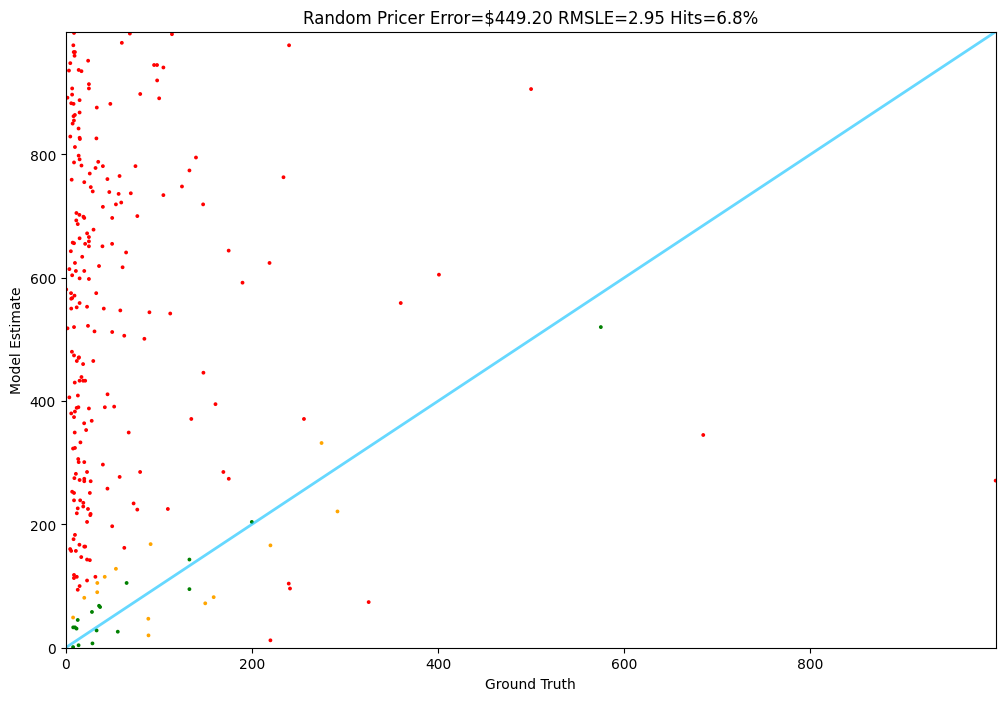

In [15]:
# Set the random seed

random.seed(42)

# Run our TestRunner
Tester.test(random_pricer)

## Average Price Guess

In [16]:
# That was fun!
# We can do better - here's another rather trivial model

training_prices = [item.price for item in train]
training_average = sum(training_prices) / len(training_prices)
print(training_prices[0])
print(training_average)

def constant_pricer(item):
    return training_average

6.4
59.549166500074264


Process status: 10% | Hits Rate so far: 52.0%
Process status: 20% | Hits Rate so far: 46.0%
Process status: 30% | Hits Rate so far: 42.7%
Process status: 40% | Hits Rate so far: 43.0%
Process status: 50% | Hits Rate so far: 41.6%
Process status: 60% | Hits Rate so far: 40.0%
Process status: 70% | Hits Rate so far: 39.4%
Process status: 80% | Hits Rate so far: 39.0%
Process status: 90% | Hits Rate so far: 40.9%
Process status: 100% | Hits Rate so far: 41.2%


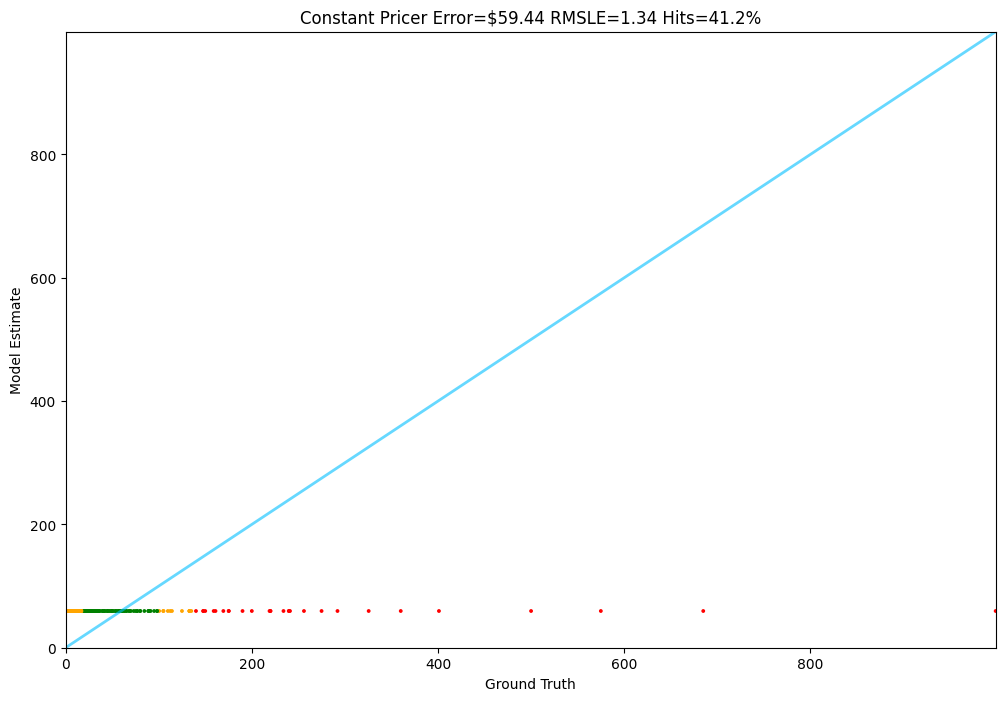

In [17]:
# Run our constant predictor
Tester.test(constant_pricer)


## 1. Features with Linear Regression

In [18]:
train[0].details

'{"Package Dimensions": "2.99 x 2.01 x 0.2 inches", "Item Weight": "1.58 ounces", "Item model number": "5647417036", "Best Sellers Rank": {"Cell Phones & Accessories": 57932, "Cell Phone Replacement Parts": 1301}, "Is Discontinued By Manufacturer": "No", "Other display features": "Wireless", "Manufacturer": "E-REPAIR", "Date First Available": "December 4, 2016"}'

In [19]:
# Create a new "features" field on items, and populate it with json parsed from the details dict

for index, item in enumerate(train):
    if index <=0:
        print (index, json.loads(item.details))
    item.features = json.loads(item.details)
for item in test:
    item.features = json.loads(item.details)

# Look at one

0 {'Package Dimensions': '2.99 x 2.01 x 0.2 inches', 'Item Weight': '1.58 ounces', 'Item model number': '5647417036', 'Best Sellers Rank': {'Cell Phones & Accessories': 57932, 'Cell Phone Replacement Parts': 1301}, 'Is Discontinued By Manufacturer': 'No', 'Other display features': 'Wireless', 'Manufacturer': 'E-REPAIR', 'Date First Available': 'December 4, 2016'}


In [20]:
print (f"Train length {len(train)}")
print (f"Test length {len(test)}")
train[0].features.keys()

Train length 100000
Test length 3000


dict_keys(['Package Dimensions', 'Item Weight', 'Item model number', 'Best Sellers Rank', 'Is Discontinued By Manufacturer', 'Other display features', 'Manufacturer', 'Date First Available'])

In [21]:
# Look at 40 most common features in training set

feature_count = Counter()
for item in train:
    for f in item.features.keys():
        feature_count[f]+=1

top_features = feature_count.most_common(40)

count = top_features[0][1]
ratio = count / len(train)
print(f"Count: {count} out of {len(train)}, Ratio is: {ratio:.2%}\n")
top_features

Count: 91857 out of 100000, Ratio is: 91.86%



[('Manufacturer', 91857),
 ('Date First Available', 86058),
 ('Item Weight', 85132),
 ('Best Sellers Rank', 82361),
 ('Brand', 82287),
 ('Item model number', 62270),
 ('Product Dimensions', 55791),
 ('Color', 47808),
 ('Material', 39884),
 ('Is Discontinued By Manufacturer', 35031),
 ('Manufacturer Part Number', 34243),
 ('Package Dimensions', 29404),
 ('Country of Origin', 28762),
 ('Special Feature', 18148),
 ('Item Dimensions LxWxH', 16008),
 ('Style', 14968),
 ('Batteries Required?', 14862),
 ('Part Number', 14456),
 ('Size', 14417),
 ('Batteries Included?', 11725),
 ('Model', 11055),
 ('Included Components', 10980),
 ('Item Package Quantity', 10936),
 ('Special Features', 10635),
 ('Number of Items', 10352),
 ('OEM Part Number', 9868),
 ('Finish Type', 9801),
 ('Shape', 9693),
 ('Manufacturer recommended age', 9288),
 ('Compatible Devices', 9197),
 ('Unit Count', 9068),
 ('Vehicle Service Type', 8647),
 ('Exterior', 8252),
 ('Number of Pieces', 7702),
 ('Theme', 7502),
 ('Mounting

In [22]:
# Now some janky code to pluck out the Item Weight
# Don't worry too much about this: spoiler alert, it's not going to be much use in training!

def get_weight(item):
    weight_str = item.features.get('Item Weight')
    if weight_str:
        parts = weight_str.split(' ')
        amount = float(parts[0])
        unit = parts[1].lower()
        if unit=="pounds":
            return amount
        elif unit=="ounces":
            return amount / 16
        elif unit=="grams":
            return amount / 453.592
        elif unit=="milligrams":
            return amount / 453592
        elif unit=="kilograms":
            return amount / 0.453592
        elif unit=="hundredths" and parts[2].lower()=="pounds":
            return amount / 100
        else:
            print(weight_str)
    return None

In [23]:
weights = [get_weight(t) for t in train]
weights = [w for w in weights if w]
print (f"Wights length: {len(weights)}")

Wights length: 85129


In [24]:
average_weight = sum(weights)/len(weights)
average_weight

3.624261197350387

In [25]:
def get_weight_with_default(item):
    weight = get_weight(item)
    return weight or average_weight

In [26]:
def get_rank(item): # BSR
    rank_dict = item.features.get("Best Sellers Rank") # BSR（Best Sellers Rank）數值越低，代表銷售越好。
    if rank_dict:
        ranks = rank_dict.values()
        # ranks = [math.log(v + 1) for v in rank_dict.values()]  # +1 to avoid log(0)
        return sum(ranks)/len(ranks)
    return None

In [27]:
print("Weight ...")
print(get_weight(train[0]))
print(get_weight_with_default(train[0]))

Weight ...
0.09875
0.09875


In [28]:
ranks = [get_rank(t) for t in train]
ranks = [r for r in ranks if r]
average_rank = sum(ranks)/len(ranks)
average_rank

301472.9773705585

In [29]:
def get_rank_with_default(item):
    rank = get_rank(item)
    return rank or average_rank

In [30]:
print("\nBSR Rank ...")
print(sum(ranks))
print(sum(ranks)/len(ranks))
print(get_rank(train[1]))
print(get_rank_with_default(train[2]))


BSR Rank ...
24792534712.99999
301472.9773705585
1612098.0
301472.9773705585


In [31]:
def get_text_length(item):
    return len(item.test_prompt())

In [32]:
# investigate the brands

brands = Counter()
for t in train:
    brand = t.features.get("Brand")
    if brand:
        brands[brand]+=1

# Look at most common 40 brands

brands.most_common(40)

[('Dorman', 718),
 ('ACDelco', 429),
 ('Generic', 419),
 ('Detroit Axle', 282),
 ('Evan Fischer', 262),
 ('HP', 257),
 ('A-Premium', 243),
 ('3dRose', 239),
 ('Power Stop', 214),
 ('Funko', 196),
 ('CafePress', 185),
 ('ECCPP', 176),
 ('MOOG', 175),
 ('Dell', 159),
 ('Beck/Arnley', 156),
 ('uxcell', 145),
 ('Rareelectrical', 140),
 ('Uxcell', 138),
 ('Magic The Gathering', 135),
 ('Gates', 135),
 ('Garage-Pro', 133),
 ('BOSCH', 131),
 ('Raybestos', 130),
 ('Standard Motor Products', 129),
 ('GM', 129),
 ('GRAPHICS & MORE', 129),
 ('X AUTOHAUX', 127),
 ('AUTOANDART', 127),
 ('Asuwish', 126),
 ('Spectra Premium', 125),
 ('TYC', 123),
 ('SAMSUNG', 122),
 ('UPBRIGHT', 121),
 ('Walker', 111),
 ('Lenovo', 108),
 ('Tuningpros', 107),
 ('APDTY', 104),
 ('Sony', 104),
 ('Auto Dynasty', 103),
 ('Fel-Pro', 102)]

In [33]:
top_40_brands = [brand for brand, _ in brands.most_common(40)]
top_40_brands

['Dorman',
 'ACDelco',
 'Generic',
 'Detroit Axle',
 'Evan Fischer',
 'HP',
 'A-Premium',
 '3dRose',
 'Power Stop',
 'Funko',
 'CafePress',
 'ECCPP',
 'MOOG',
 'Dell',
 'Beck/Arnley',
 'uxcell',
 'Rareelectrical',
 'Uxcell',
 'Magic The Gathering',
 'Gates',
 'Garage-Pro',
 'BOSCH',
 'Raybestos',
 'Standard Motor Products',
 'GM',
 'GRAPHICS & MORE',
 'X AUTOHAUX',
 'AUTOANDART',
 'Asuwish',
 'Spectra Premium',
 'TYC',
 'SAMSUNG',
 'UPBRIGHT',
 'Walker',
 'Lenovo',
 'Tuningpros',
 'APDTY',
 'Sony',
 'Auto Dynasty',
 'Fel-Pro']

In [34]:
top_40_brands_lower = [brand.lower() for brand in top_40_brands]
TOP_ELECTRONICS_BRANDS = ["hp", "dell", "lenovo", "samsung", "asus", "sony", "canon", "apple", "intel"]
# combined_brands = list(set(TOP_ELECTRONICS_BRANDS + top_40_brands_lower))
combined_brands = list(set(TOP_ELECTRONICS_BRANDS))
combined_brands

['asus', 'lenovo', 'intel', 'hp', 'samsung', 'sony', 'dell', 'canon', 'apple']

In [35]:
# TOP_ELECTRONICS_BRANDS = ["hp", "dell", "lenovo", "samsung", "asus", "sony", "canon", "apple", "intel"]
def is_top_electronics_brand(item):
    brand = item.features.get("Brand")
    # return brand and brand.lower() in TOP_ELECTRONICS_BRANDS
    return brand and brand.lower() in combined_brands

In [36]:
def get_features(item):
    return {
        "weight": get_weight_with_default(item),
        "rank": get_rank_with_default(item),
        "text_length": get_text_length(item),
        "is_top_electronics_brand": 1 if is_top_electronics_brand(item) else 0
    }

In [37]:
# Look at features in a training item
get_features(train[0])

{'weight': 0.09875,
 'rank': 29616.5,
 'text_length': 646,
 'is_top_electronics_brand': 0}

In [38]:
# A utility function to convert our features into a pandas dataframe

def list_to_dataframe(items):
    features = [get_features(item) for item in items]
    df = pd.DataFrame(features)
    df['price'] = [item.price for item in items]
    return df

train_df = list_to_dataframe(train)
test_df = list_to_dataframe(test[:500])

### Co-efficients

- y = β0 + β1* x1 + β2 * x2 + ... + βn * xn \n
- intercept = β0

In [39]:
# Traditional Linear Regression!

np.random.seed(42)

# Separate features and target
feature_columns = ['weight', 'rank', 'text_length', 'is_top_electronics_brand']

X_train = train_df[feature_columns]
y_train = train_df['price']
X_test = test_df[feature_columns]
y_test = test_df['price']

# Train a Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

print("COEF ....\n")
for feature, coef in zip(feature_columns, model.coef_):
    print(f"{feature}: {coef}")
    
print(f"\nIntercept: {model.intercept_}")

# Predict the test set and evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared Score: {r2}")

COEF ....

weight: 1.410153377521733
rank: 3.3523352819214874e-05
text_length: 0.013890660768544045
is_top_electronics_brand: 237.51645006988227

Intercept: 31.45255224594868
Mean Squared Error: 9207.304024601017
R-squared Score: 0.1821303202577872


In [40]:
# Function to predict price for a new item

def linear_regression_pricer(item):
    features = get_features(item)
    features_df = pd.DataFrame([features])
    return model.predict(features_df)[0]

Process status: 10% | Hits Rate so far: 68.0%
Process status: 20% | Hits Rate so far: 68.0%
Process status: 30% | Hits Rate so far: 60.0%
Process status: 40% | Hits Rate so far: 59.0%
Process status: 50% | Hits Rate so far: 59.2%
Process status: 60% | Hits Rate so far: 60.0%
Process status: 70% | Hits Rate so far: 61.1%
Process status: 80% | Hits Rate so far: 60.5%
Process status: 90% | Hits Rate so far: 61.8%
Process status: 100% | Hits Rate so far: 61.6%


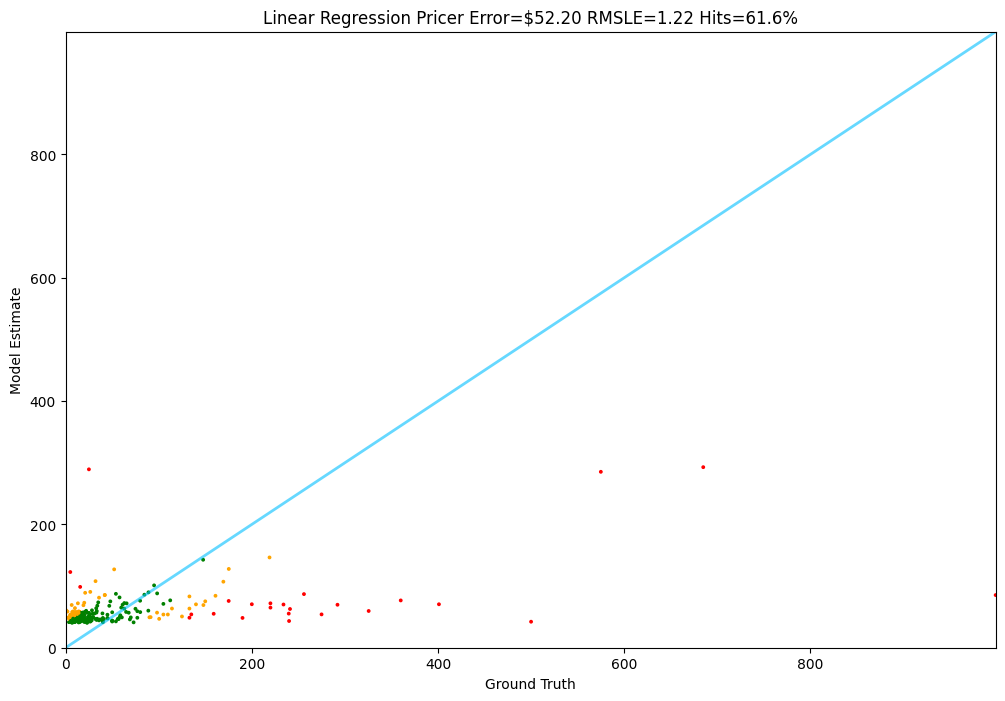

In [41]:
# test it

Tester.test(linear_regression_pricer)

## 2. Bag of Words & Linear Regression

In [42]:
# For the next few models, we prepare our documents and prices
# Note that we use the test prompt for the documents, otherwise we'll reveal the answer!!

prices = np.array([float(item.price) for item in train])
documents = [item.test_prompt() for item in train]

In [43]:
print(prices[0], "\n", documents[0])
print(len(test))

6.4 
 How much does this cost to the nearest dollar?

E-repair Complete Full Set Screws Replacement for iPhone 7
1x Full screw set for iPhone 7 1x Clean Wiper Come with bottom screws 2x gold, 2x silver, 2x black. Including Clean Wiper with E-REPAIR LOGO Compatible with iPhone 7 It is full set screws to assemble a complete phone. Including bottom Pentalobe Screws black, silver and gold colors Dimensions 2.99 x 2.01 x 0.2 inches, Weight 1.58 ounces, model number Rank Cell Phones & Accessories 57932, Cell Phone Replacement Parts 1301, Is Discontinued No, Other display features Wireless, Manufacturer E-REPAIR, Available December 4, 2016

Price is $
3000


In [44]:
# Use the CountVectorizer for a Bag of Words model

np.random.seed(42)
vectorizer = CountVectorizer(max_features=1000, stop_words='english')
X = vectorizer.fit_transform(documents)
regressor = LinearRegression()
regressor.fit(X, prices)

LinearRegression()

In [45]:
def bow_lr_pricer(item):
    x = vectorizer.transform([item.test_prompt()])
    return max(regressor.predict(x)[0], 0)

Process status: 10% | Hits Rate so far: 52.0%
Process status: 20% | Hits Rate so far: 66.0%
Process status: 30% | Hits Rate so far: 64.0%
Process status: 40% | Hits Rate so far: 60.0%
Process status: 50% | Hits Rate so far: 62.4%
Process status: 60% | Hits Rate so far: 62.7%
Process status: 70% | Hits Rate so far: 64.0%
Process status: 80% | Hits Rate so far: 64.5%
Process status: 90% | Hits Rate so far: 65.3%
Process status: 100% | Hits Rate so far: 65.2%


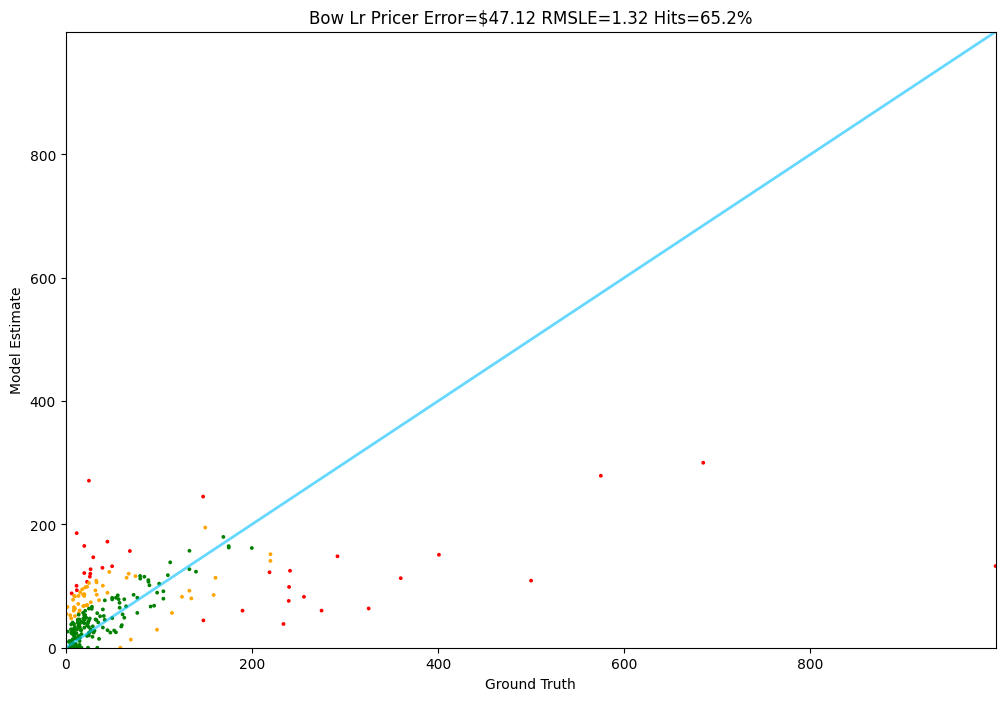

In [46]:
# test it

Tester.test(bow_lr_pricer)

## 3. word2vec & Linear Regression
- vec("king")−vec("man")+vec("woman")≈vec("queen")

- Word2Vec 有兩種訓練方式：
    1. CBOW (Continuous Bag of Words)：根據上下文預測中心詞
    2. Skip-Gram：根據中心詞預測上下文（更常用）

In [47]:
# The amazing word2vec model, implemented in gensim NLP library

np.random.seed(42)

# Preprocess the documents => documents = [item.test_prompt() for item in train]
processed_docs = [simple_preprocess(doc) for doc in documents]

# Train Word2Vec model
w2v_model = Word2Vec(sentences=processed_docs, vector_size=400, window=5, min_count=1, workers=8)

In [48]:
print(processed_docs[0])

['how', 'much', 'does', 'this', 'cost', 'to', 'the', 'nearest', 'dollar', 'repair', 'complete', 'full', 'set', 'screws', 'replacement', 'for', 'iphone', 'full', 'screw', 'set', 'for', 'iphone', 'clean', 'wiper', 'come', 'with', 'bottom', 'screws', 'gold', 'silver', 'black', 'including', 'clean', 'wiper', 'with', 'repair', 'logo', 'compatible', 'with', 'iphone', 'it', 'is', 'full', 'set', 'screws', 'to', 'assemble', 'complete', 'phone', 'including', 'bottom', 'pentalobe', 'screws', 'black', 'silver', 'and', 'gold', 'colors', 'dimensions', 'inches', 'weight', 'ounces', 'model', 'number', 'rank', 'cell', 'phones', 'accessories', 'cell', 'phone', 'replacement', 'parts', 'is', 'discontinued', 'no', 'other', 'display', 'features', 'wireless', 'manufacturer', 'repair', 'available', 'december', 'price', 'is']


In [49]:
# This step of averaging vectors across the document is a weakness in our approach

def document_vector(doc):
    doc_words = simple_preprocess(doc)
    word_vectors = [w2v_model.wv[word] for word in doc_words if word in w2v_model.wv]
    return np.mean(word_vectors, axis=0) if word_vectors else np.zeros(w2v_model.vector_size)

# Create feature matrix
X_w2v = np.array([document_vector(doc) for doc in documents])

In [50]:
# Run Linear Regression on word2vec

word2vec_lr_regressor = LinearRegression()
word2vec_lr_regressor.fit(X_w2v, prices)

LinearRegression()

In [51]:
def word2vec_lr_pricer(item):
    doc = item.test_prompt()
    doc_vector = document_vector(doc)
    return max(0, word2vec_lr_regressor.predict([doc_vector])[0])

Process status: 10% | Hits Rate so far: 52.0%
Process status: 20% | Hits Rate so far: 54.0%
Process status: 30% | Hits Rate so far: 60.0%
Process status: 40% | Hits Rate so far: 58.0%
Process status: 50% | Hits Rate so far: 60.8%
Process status: 60% | Hits Rate so far: 60.7%
Process status: 70% | Hits Rate so far: 61.1%
Process status: 80% | Hits Rate so far: 63.0%
Process status: 90% | Hits Rate so far: 63.6%
Process status: 100% | Hits Rate so far: 63.2%


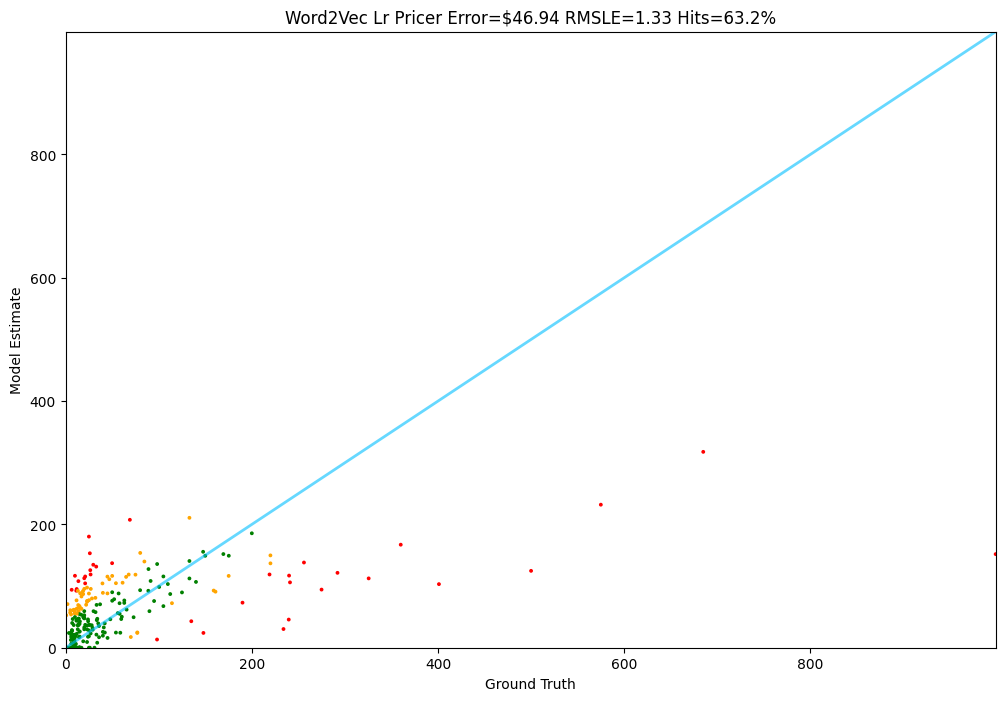

In [52]:
Tester.test(word2vec_lr_pricer)

## 4. word2vec & SVR

### 4.1 SVR Sample

Predicted price: 695.0 ×10,000 TWD


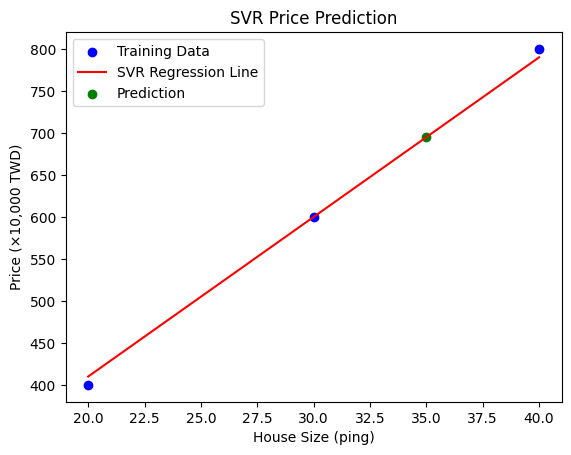

In [53]:
# House size (in ping)
X = np.array([[20], [30], [40]])
# Corresponding price (in 10,000 TWD)
y = np.array([400, 600, 800])

# Build SVR model
model = SVR(kernel='linear', C=100, epsilon=10)
model.fit(X, y)

# Predict the price for 35 ping
predicted = model.predict([[35]])
print("Predicted price:", predicted[0], "×10,000 TWD")

# Plot the results
plt.scatter(X, y, color='blue', label='Training Data')
plt.plot(X, model.predict(X), color='red', label='SVR Regression Line')
plt.scatter([[35]], predicted, color='green', label='Prediction')

plt.legend()
plt.xlabel('House Size (ping)')
plt.ylabel('Price (×10,000 TWD)')
plt.title('SVR Price Prediction')
plt.show()


### 4.2 SVR Testing

In [54]:
# SVR - Support Vector Regression

np.random.seed(42)
svr_regressor = LinearSVR()

svr_regressor.fit(X_w2v, prices)

LinearSVR()

In [55]:
def svr_pricer(item):
    np.random.seed(42)
    doc = item.test_prompt()
    doc_vector = document_vector(doc)
    return max(float(svr_regressor.predict([doc_vector])[0]),0)

Process status: 10% | Hits Rate so far: 80.0%
Process status: 20% | Hits Rate so far: 76.0%
Process status: 30% | Hits Rate so far: 76.0%
Process status: 40% | Hits Rate so far: 76.0%
Process status: 50% | Hits Rate so far: 76.0%
Process status: 60% | Hits Rate so far: 78.0%
Process status: 70% | Hits Rate so far: 77.7%
Process status: 80% | Hits Rate so far: 78.5%
Process status: 90% | Hits Rate so far: 79.6%
Process status: 100% | Hits Rate so far: 78.8%


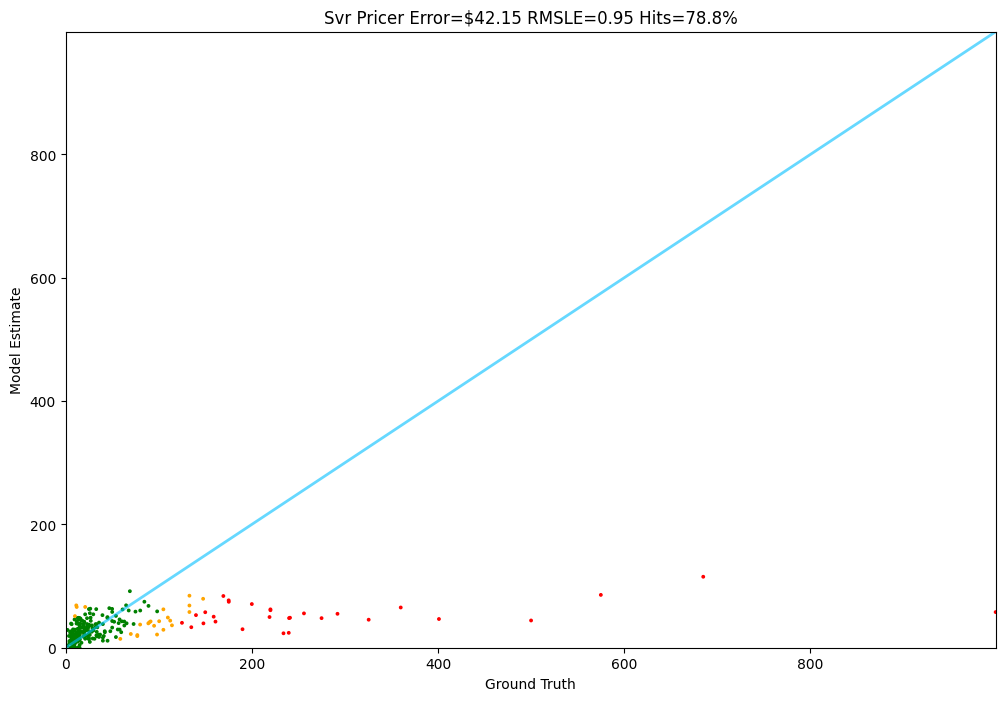

In [56]:
Tester.test(svr_pricer)

## 4.3 Hist Gradient Boosting

In [57]:
from sklearn.ensemble import HistGradientBoostingRegressor
model = HistGradientBoostingRegressor(random_state=42)
model.fit(X_w2v, prices)

HistGradientBoostingRegressor(random_state=42)

In [58]:
def hist_gb_pricer(item):
    doc = item.test_prompt()
    doc_vector = document_vector(doc)
    return max(0, model.predict([doc_vector])[0])


Process status: 10% | Hits Rate so far: 56.0%
Process status: 20% | Hits Rate so far: 62.0%
Process status: 30% | Hits Rate so far: 69.3%
Process status: 40% | Hits Rate so far: 68.0%
Process status: 50% | Hits Rate so far: 68.0%
Process status: 60% | Hits Rate so far: 68.0%
Process status: 70% | Hits Rate so far: 69.7%
Process status: 80% | Hits Rate so far: 71.0%
Process status: 90% | Hits Rate so far: 72.0%
Process status: 100% | Hits Rate so far: 72.0%


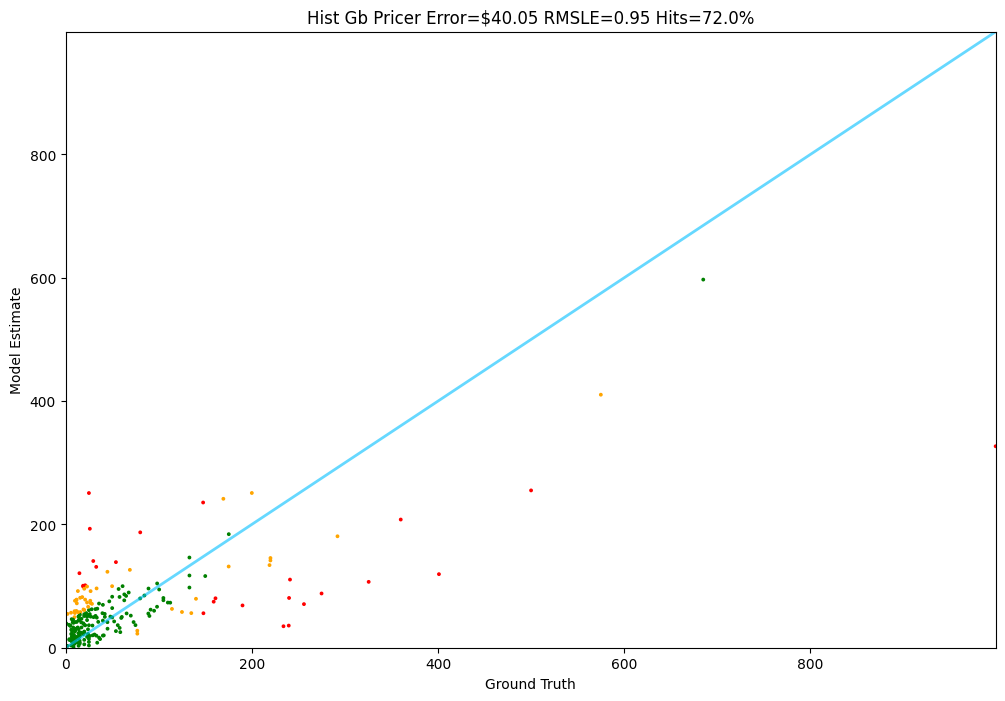

In [59]:
Tester.test(hist_gb_pricer)

## 5. word2vec & Random Forest

In [ ]:
# And the powerful Random Forest regression

# # rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=8)
# rf_model = RandomForestRegressor(n_estimators=20, random_state=42, n_jobs=8)
# rf_model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf_model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=4)
rf_model.fit(X_w2v, prices)

In [ ]:
def random_forest_pricer(item):
    doc = item.test_prompt()
    doc_vector = document_vector(doc)
    return max(0, rf_model.predict([doc_vector])[0])

In [ ]:
Tester.test(random_forest_pricer)

In [ ]:
# 設定 seed ⇒ 每次執行結果一樣（看起來亂，但其實是固定的）
random.seed(12)
print(random.randint(1, 100))
print(random.randint(1, 100))
print(random.randint(1, 100))
print(random.randint(1, 100))